In [1]:
import numpy as np
import matplotlib.pyplot as plt

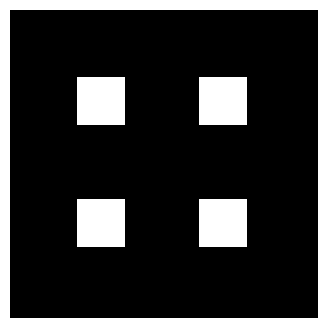

In [14]:
# H, W = 65, 65
# rows, cols = 8, 8            # number of sensors vertically and horizontally
# sensor_h, sensor_w = 4, 6    # each sensor block size
# spacing_y, spacing_x = 4, 2  # more vertical spacing between rows

H, W = 96, 96
rows, cols = 2, 2      # number of sensors vertically and horizontally
sensor_h, sensor_w = 15, 15   # each sensor block size
spacing_y, spacing_x = 23, 23  # more vertical spacing between rows

# Compute total pattern size
pattern_h = rows * sensor_h + (rows - 1) * spacing_y
pattern_w = cols * sensor_w + (cols - 1) * spacing_x

# Center the pattern in the full image
y_start = (H - pattern_h) // 2
x_start = (W - pattern_w) // 2

# Initialize mask
sensor_mask = np.zeros((H, W), dtype=np.float32) 
sensor_mask_offset = np.ones((H,W), dtype=np.float32) * 10

# Fill rectangular sensor regions
for r in range(rows):
    for c in range(cols):
        y0 = y_start + r * (sensor_h + spacing_y)
        y1 = y0 + sensor_h
        x0 = x_start + c * (sensor_w + spacing_x)
        x1 = x0 + sensor_w
        sensor_mask[y0:y1, x0:x1] = 1.0  # active region

# Visualize
plt.figure(figsize=(4,4))
plt.imshow(sensor_mask, cmap='gray', vmin=0, vmax=1)
# plt.title("sensor grid")
plt.axis('off')
plt.show()


Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/juliama/miniconda3/envs/waller_env/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 201, in _version_check
    version = get_version()
              ^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:85: operation cusparseGetProperty(MAJOR_VERSION, &major) failed: The cuSPARSE library was not found.

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/juliama/miniconda3/envs/waller_env/lib/python3.11/site-packages/jax/_src/xla_bridge.py", line 497, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/juliama/miniconda3/envs/waller_env/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 348, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/juliama/miniconda3/envs/waller_env/lib/python3.1

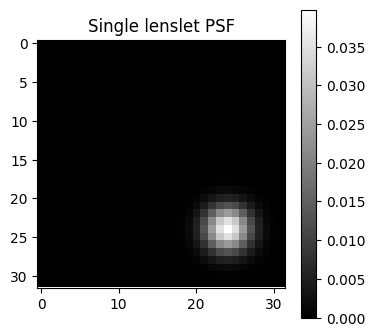

In [18]:
import numpy as np
import jax.numpy as jnp

def make_single_lenslet_psf(psf_size=(32, 32), sigma=2.0):
    """
    Single Gaussian PSF positioned in the bottom-right,
    matching the sensor mask layout.
    """
    H, W = psf_size
    
    # position in bottom-right quadrant
    center_y = int(H * 0.75)  # 3/4 down
    center_x = int(W * 0.75)  # 3/4 right
    
    y = np.arange(H)
    x = np.arange(W)
    X, Y = np.meshgrid(x, y)
    
    psf = np.exp(-((X - center_x)**2 + (Y - center_y)**2) / (2 * sigma**2))
    psf = psf / psf.sum()  # normalize
    
    return jnp.array(psf, dtype=jnp.float32)

psf = make_single_lenslet_psf(psf_size=(32, 32), sigma=2.0)

# visualize
plt.figure(figsize=(4, 4))
plt.imshow(np.array(psf), cmap='gray')
plt.colorbar()
plt.title('Single lenslet PSF')
plt.show()

In [ ]:
from scipy.signal import convolve2d